Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
df = pd.read_csv('sleep_health_dataset.csv')
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [3]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [4]:
df.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [5]:
df.duplicated().sum()

np.int64(0)


Data Analysis (EDA)


Sleep quality by Gender

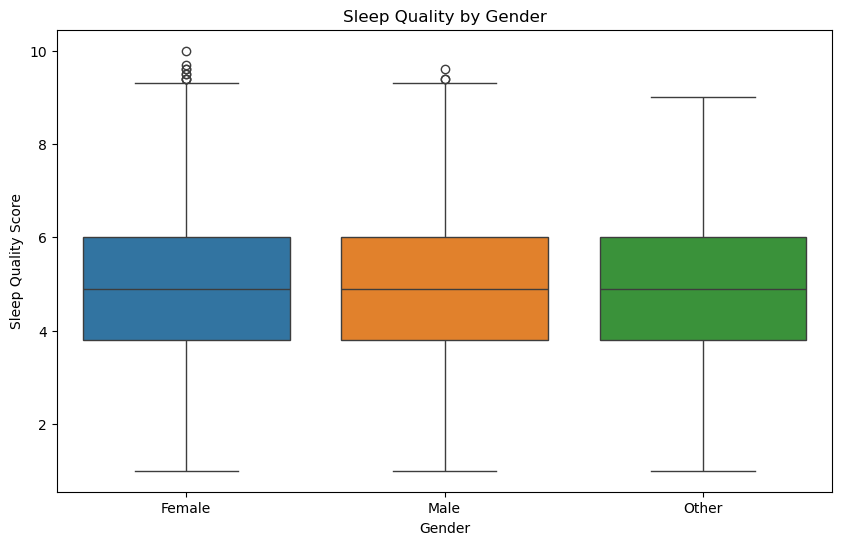

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='gender', y='sleep_quality_score', hue='gender')
plt.title('Sleep Quality by Gender')
plt.xlabel('Gender')
plt.ylabel('Sleep Quality Score')
plt.show()

The box plot reveals the density of sleep quality across genders. Both genders show a broad range of scores with sleep quality score most densed between 3-7.



 Correlation Matrix of Health Metrics


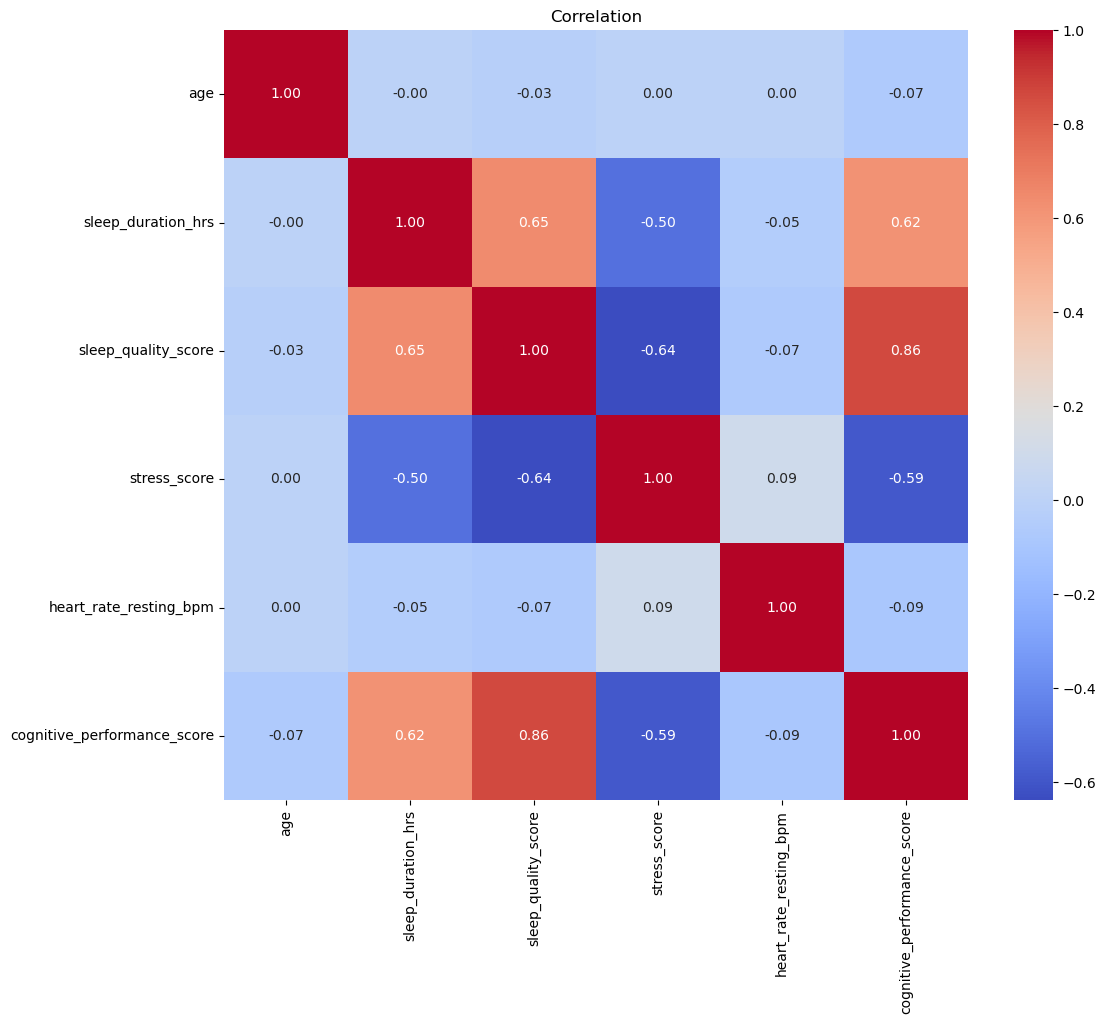

In [7]:
plt.figure(figsize=(12, 10))
corr = df[['age', 'sleep_duration_hrs', 'sleep_quality_score', 'stress_score',
'heart_rate_resting_bpm', 'cognitive_performance_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation')
plt.show()

There is a strong negative correlation between stress_score and sleep_quality_score. Conversely, sleep_duration_hrs and sleep_quality_score tend to have a strong positive correlation, suggesting that longer sleep often translates to perceived better quality.

 Sleep Disorder Risk across Occupations


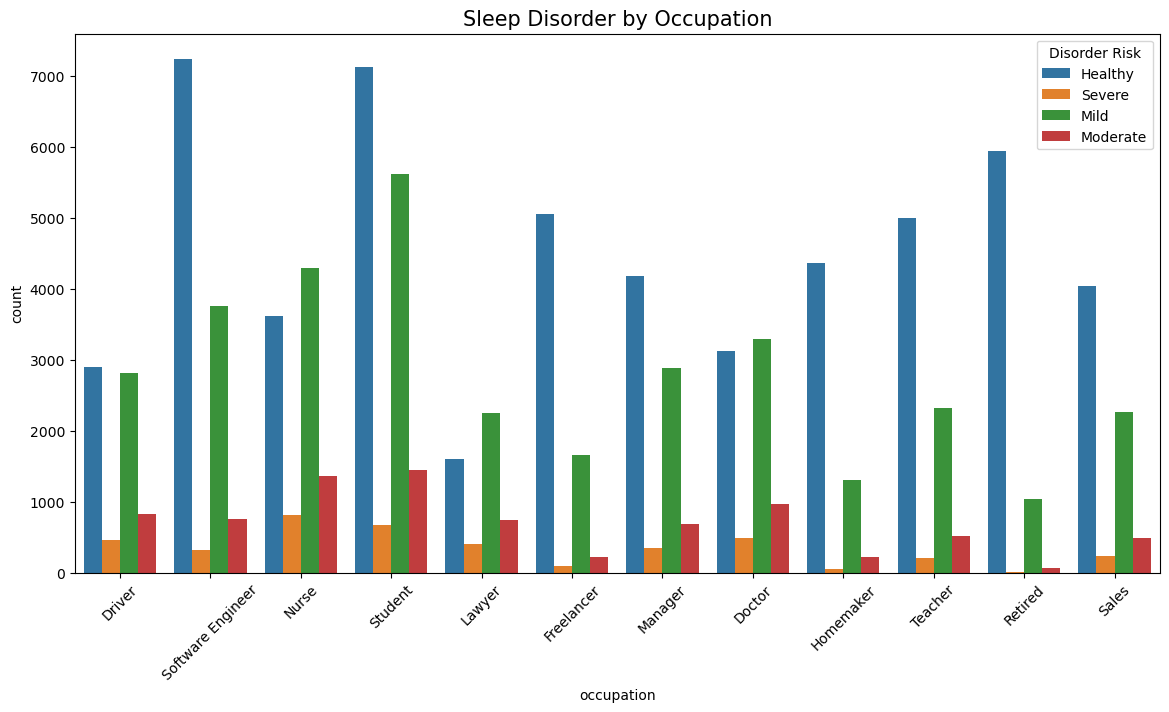

In [8]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='occupation', hue='sleep_disorder_risk')
plt.title('Sleep Disorder by Occupation', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Disorder Risk')
plt.show()

Occupational stress significantly impacts sleep health. Professionals like Doctors and Nurses often report higher "Severe" or "Moderate" risk levels for sleep disorders compared to "Retired" individuals, who frequently show "Healthy" sleep profiles. Surprisingly enough, Students report higher "Severe" or "Moderate" risk levels for sleep disorders.

 Sleep Duration vs. Cognitive Performance


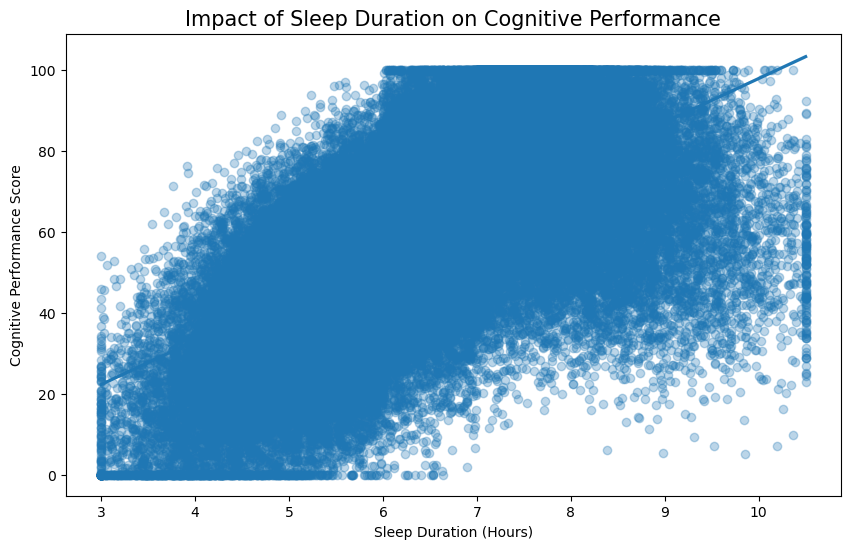

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='sleep_duration_hrs', y='cognitive_performance_score',
            scatter_kws={'alpha':0.3})
plt.title('Impact of Sleep Duration on Cognitive Performance', fontsize=15)
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Cognitive Performance Score')
plt.show()

The regression line indicates a positive trend where increased sleep duration leads to higher cognitive performance scores. Low sleep duration (below 5 hours) is frequently associated with significantly lower cognitive output.

Caffeine Consumption vs. Sleep Latency


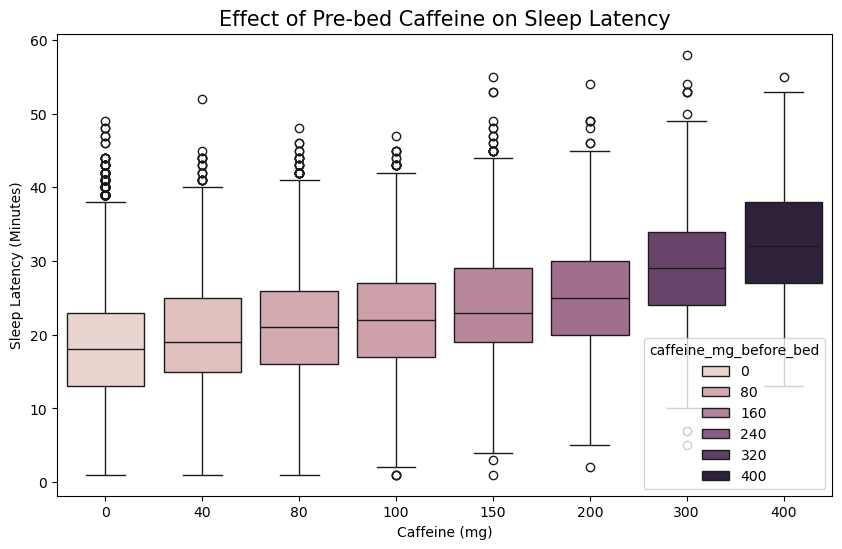

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='caffeine_mg_before_bed', y='sleep_latency_mins', hue='caffeine_mg_before_bed')
plt.title('Effect of Pre-bed Caffeine on Sleep Latency', fontsize=15)
plt.xlabel('Caffeine (mg)')
plt.ylabel('Sleep Latency (Minutes)')
plt.show()

Higher intake of caffeine before bed (e.g., 300mg+) is associated with increased sleep latency, meaning individuals take longer to fall asleep. Those with zero caffeine consumption generally show shorter, healthier latency periods.

Checking if data balanced

C:\Users\medoc\AppData\Local\Temp\ipykernel_36936\1348100896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sleep_disorder_risk', ax=axes[0], palette='viridis')


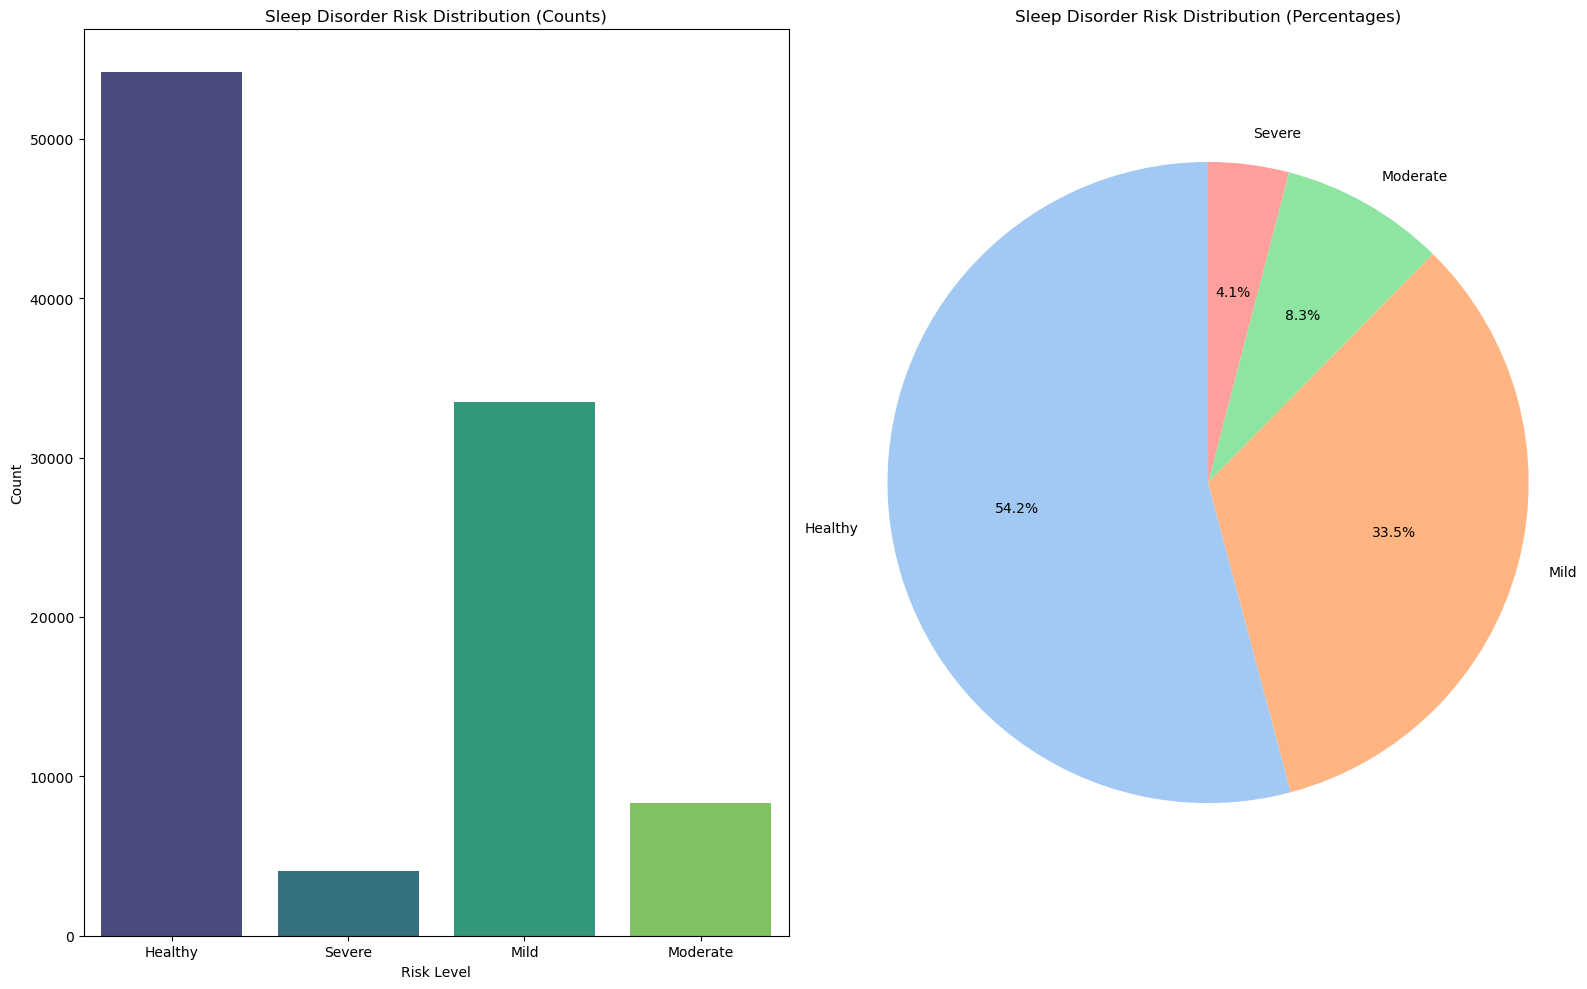

In [11]:
risk_counts = df['sleep_disorder_risk'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
sns.countplot(data=df, x='sleep_disorder_risk', ax=axes[0], palette='viridis')
axes[0].set_title('Sleep Disorder Risk Distribution (Counts)')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[1].pie(risk_counts,
            labels=risk_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=sns.color_palette('pastel')) 
axes[1].set_title('Sleep Disorder Risk Distribution (Percentages)')
axes[1].axis('equal')
plt.tight_layout()
plt.show()

The plots reveals that the data is imbalanced 

 Data Preprocessing & Feature Engineering


In [12]:
# Drop unique identifiers
df = df.drop(columns=['person_id'])

# Encode Categorical Variables
categorical_cols = ['gender', 'occupation', 'country', 'chronotype',
                    'mental_health_condition', 'season', 'day_type']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define Features and Target
X = df.drop(columns=['sleep_disorder_risk'])
y = df['sleep_disorder_risk']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE for imbalanced classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)



 Model Training: Random Forest


Random Forest is suitable for this dataset because the data is structured and contains multiple health and lifestyle factors that may interact in complex, nonlinear ways. The model can handle both numerical and categorical variables, is robust to overfitting, requires limited preprocessing, and provides feature importance that helps interpret which factors most influence the prediction of sleep disorders.

In [13]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,3]
}

# Initialize a RandomForestClassifier
rf_base_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_base_model, param_grid=param_grid,
cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.2%}")

# Train the final model with the best parameters
rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Overfitting Check

from sklearn.model_selection import cross_val_score

# Training predictions
y_train_pred = rf_model.predict(X_train_resampled)

# Training accuracy
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Test accuracy
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")
print(f"Accuracy Gap: {(train_acc - test_acc):.2%}")

# Cross-validation on resampled training data
cv_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')

print(f"Cross-validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2%}")
print(f"CV Std: {cv_scores.std():.2%}")

# Simple conclusion
if train_acc - test_acc > 0.1:
    print("Warning: The model may be overfitting.")
else:
    print("No strong overfitting signal based on the train-test accuracy gap.")
# Evaluation
print(f"\nModel Accuracy (with best params): {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report (with best params):\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-validation Accuracy: 79.35%
Training Accuracy: 82.16%
Test Accuracy: 83.55%
Accuracy Gap: -1.39%
Cross-validation Accuracy Scores: [0.76808621 0.81205397 0.80925139 0.80150819 0.7941117 ]
Mean CV Accuracy: 79.70%
CV Std: 1.58%
No strong overfitting signal based on the train-test accuracy gap.

Model Accuracy (with best params): 83.55%

Classification Report (with best params):
               precision    recall  f1-score   support

     Healthy       0.94      0.91      0.92     10892
        Mild       0.79      0.80      0.79      6673
    Moderate       0.49      0.58      0.53      1626
      Severe       0.66      0.70      0.68       809

    accuracy                           0.84     20000
   macro avg       0.72      0.74      0.73     20000
weighted avg       0.84      0.84      0.84     20000



 Feature Importance Analysis


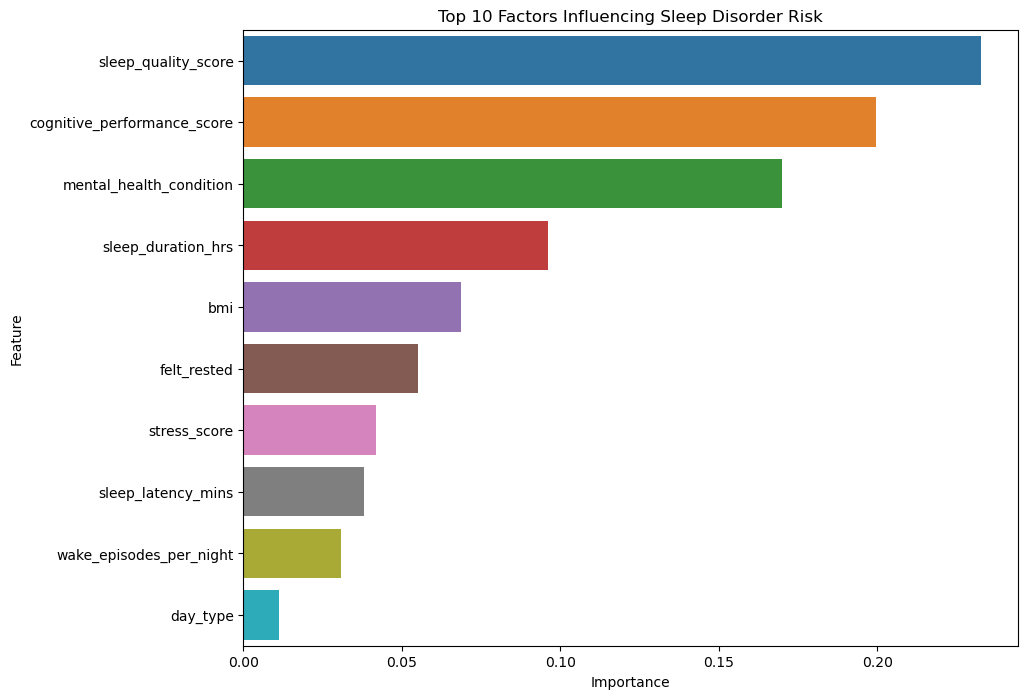

In [14]:
# Extract feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(10), legend=False)
plt.title('Top 10 Factors Influencing Sleep Disorder Risk')
plt.show()

 Confusion Matrix Visualization


<Figure size 1000x800 with 0 Axes>

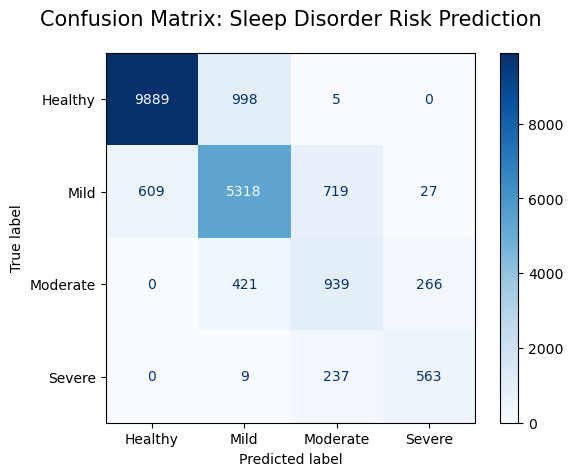

In [18]:
cm = confusion_matrix(y_test, y_pred)

labels = rf_model.classes_

# Plotting
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Sleep Disorder Risk Prediction', fontsize=15, pad=20)
plt.grid(False)
plt.show()

The model is very good at identifying healthy cases, fairly good at mild and severe cases, and has the most trouble distinguishing between moderate and severe or mild and moderate. Most errors are close misses rather than completely wrong predictions.

In [16]:
import joblib

# Define the filename for the saved model
model_filename = 'random_forest_model.pkl'

# Save the trained model to the file
joblib.dump(rf_model, model_filename)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'random_forest_model.pkl'
